# Elasticity regimes — corr(VLM, PIM) by DCM

**Paper:** §3 motivational elasticity (PDF pp. 15–19) · **NOTES:** [`NOTES.md`](NOTES.md) · **EXP:** [`EXP_REPORT.md`](EXP_REPORT.md)  
**Artifacts:** `out/elasticity_regimes/`

Paper: volume–inefficiency co-movement **weakens** when dealers are constrained. Certified-panel crypto join finds **negative** pooled corr(VLM, PIM) **n=88** corr≈**−0.46** CI[−0.57,−0.35] — **not** a soft-Promote of the FX result (clock/unit/TOB sparsity). Decision ceiling remains **Hold**. `trade_synth` quarantined.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "cd_me"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]  # ares-microstructure repo root (research.lib absolute imports)
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, expand_pim_hourly, expand_dcm_hourly, day_summary_table, SIGNAL_BOARD,
    load_kraken_inventory, kraken_mode_for_day,
)
from certified_panel import load_certified, primary_days, spot_l2_days
from research.lib import cdme  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

PASS2 = OUT / "pass2"
KR_INV = load_kraken_inventory(BOOK)
CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("pass2 present", PASS2.is_dir(), "falsifiers", (PASS2 / "pass2_falsifiers.json").is_file())
print("trade_synth QUARANTINED — never primary")


BOOK /home/dev/srv/ares-microstructure/research/books/cd_me
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
spot_l2 subpanel n= 4 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
pass2 present True falsifiers True
trade_synth QUARANTINED — never primary


In [2]:

el = load_json(OUT / "elasticity_regimes" / "summary.json")
dcm_panel = load_json(OUT / "dcm_proxies" / "panel_rows.json") or []
hourly = expand_dcm_hourly(dcm_panel)
pooled = (el or {}).get("pooled") or {}
print(json.dumps({
    "n_ok": None if not el else el.get("n_ok"),
    "pooled_all": pooled.get("all"),
    "regime_point": pooled.get("regime_point"),
    "decision_ceiling": pooled.get("decision_ceiling"),
    "honesty": None if not el else el.get("honesty"),
}, indent=2, default=str))
day_el = pd.DataFrame((el or {}).get("day_elasticity") or [])
if len(day_el):
    display(day_el)


{
  "n_ok": 9,
  "pooled_all": {
    "ok": true,
    "n": 88,
    "corr": -0.4612833556222188,
    "ci_lo": -0.5697748432382688,
    "ci_hi": -0.35269499514070435,
    "n_boot": 800
  },
  "regime_point": {
    "ok": true,
    "corr_low": -0.4893284681016839,
    "corr_high": -0.5955304634537502,
    "delta": -0.10620199535206626,
    "n_low": 15,
    "n_high": 26,
    "q_low": -1.5865040328978965,
    "q_high": 0.03995832935775736,
    "low_q": 0.25,
    "high_q": 0.75
  },
  "decision_ceiling": "Hold",
  "honesty": "Hold after Pass-2 falsifiers; min_n=5 exploratory only \u2014 never soft-Promote; TOB-cross \u03b1 Kill; primary=panel_core_2venue real quotes; trade_synth QUARANTINED"
}


,day,ok,elasticity
0,2026-09-14,True,"{'all': {'corr': -0.32010728790062026, 'n': 13..."
1,2026-09-15,True,"{'all': {'corr': None, 'n': 3, 'ok': False}, '..."
2,2026-09-16,True,"{'all': {'corr': -0.44319204598210366, 'n': 11..."
3,2026-09-17,True,"{'all': {'corr': -0.3405506729877398, 'n': 10,..."
4,2026-09-18,True,"{'all': {'corr': -0.629291557860373, 'n': 13, ..."
5,2026-09-25,True,"{'all': {'corr': -0.4998721697750468, 'n': 13,..."
6,2026-09-26,True,"{'all': {'corr': -0.18376124721309467, 'n': 13..."
7,2026-09-27,True,"{'all': {'corr': -0.49756679039818485, 'n': 12..."
8,2026-10-01,True,"{'all': {'corr': None, 'n': 0, 'ok': False}, '..."


## Pass-2 figures


**fig_elasticity_by_day.png** — `out/elasticity_regimes/figs/fig_elasticity_by_day.png`

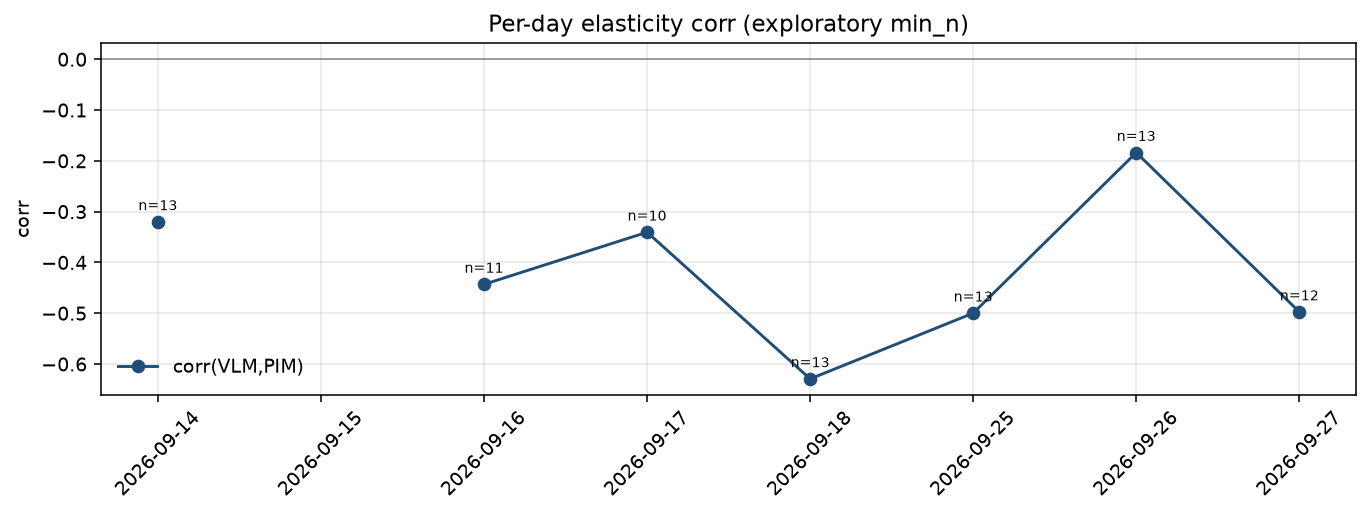

**fig_elasticity_pooled_ci.png** — `out/elasticity_regimes/figs/fig_elasticity_pooled_ci.png`

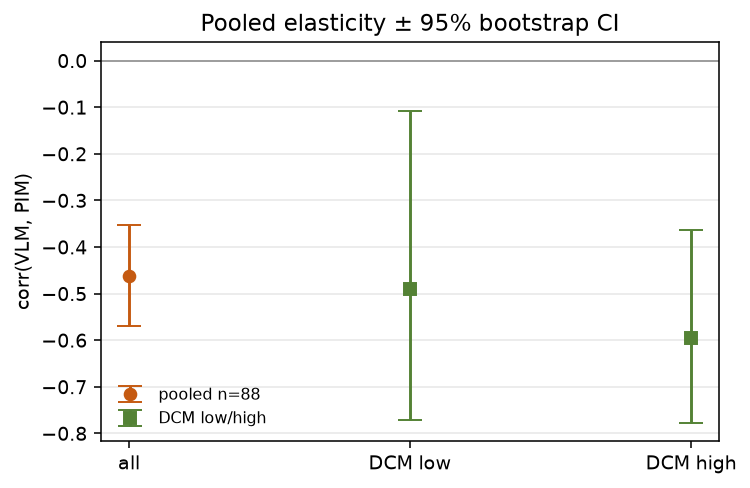

In [3]:
show_pngs(OUT / "elasticity_regimes" / "figs")


## Expansion — scatter VLM vs PIM with DCM color + regime strips


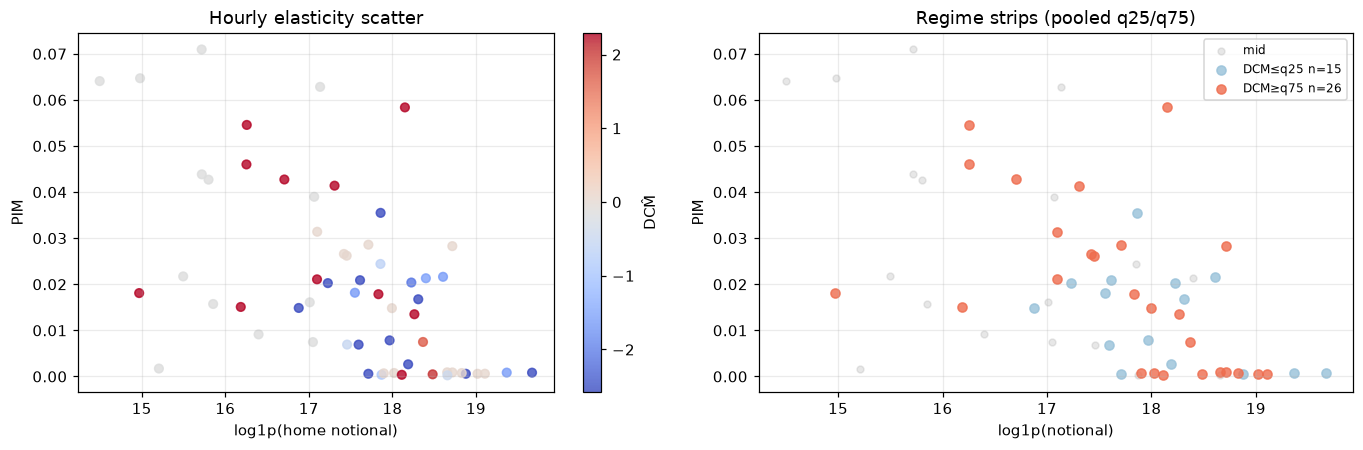

pooled corr -0.4612833556222188 n 88


In [4]:

ok = hourly[np.isfinite(hourly["pim"]) & np.isfinite(hourly["notional"])].copy()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
c = ok["dcm"] if "dcm" in ok else np.zeros(len(ok))
sc = ax.scatter(np.log1p(ok["notional"]), ok["pim"], c=c, cmap="coolwarm", s=32, alpha=0.8)
ax.set_xlabel("log1p(home notional)"); ax.set_ylabel("PIM"); ax.set_title("Hourly elasticity scatter")
fig.colorbar(sc, ax=ax, label="DCM̂")

# regime split using pooled quantiles when available
reg = pooled.get("regime_point") or {}
q_lo, q_hi = reg.get("q_low"), reg.get("q_high")
ax = axes[1]
if q_lo is not None and q_hi is not None and np.isfinite(ok["dcm"]).any():
    low = ok[ok["dcm"] <= q_lo]
    high = ok[ok["dcm"] >= q_hi]
    mid = ok[(ok["dcm"] > q_lo) & (ok["dcm"] < q_hi)]
    ax.scatter(np.log1p(mid["notional"]), mid["pim"], s=20, alpha=0.35, c="#bbb", label="mid")
    ax.scatter(np.log1p(low["notional"]), low["pim"], s=36, alpha=0.8, c="#98c1d9", label=f"DCM≤q25 n={len(low)}")
    ax.scatter(np.log1p(high["notional"]), high["pim"], s=36, alpha=0.8, c="#ee6c4d", label=f"DCM≥q75 n={len(high)}")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "regime quantiles unavailable", ha="center", transform=ax.transAxes)
ax.set_xlabel("log1p(notional)"); ax.set_ylabel("PIM"); ax.set_title("Regime strips (pooled q25/q75)")
plt.tight_layout(); plt.show()
print("pooled corr", ok["notional"].corr(ok["pim"]), "n", len(ok))


## Expansion — day-by-day corr + chronological sensitivity


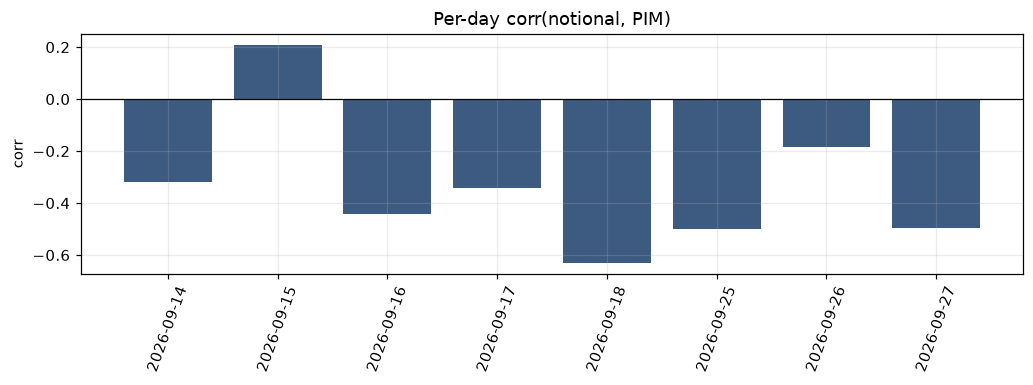

,day,n,corr
0,2026-09-14,13,-0.3201
1,2026-09-15,3,0.2079
2,2026-09-16,11,-0.4432
3,2026-09-17,10,-0.3406
4,2026-09-18,13,-0.6293
5,2026-09-25,13,-0.4999
6,2026-09-26,13,-0.1838
7,2026-09-27,12,-0.4976


early days ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17'] corr -0.31353529910393085 n 37
late days ['2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27'] corr -0.5435873195132339 n 51


In [5]:

# recompute per-day corr from hourly join
rows = []
for day, g in ok.groupby("day"):
    if len(g) >= 3:
        rows.append({"day": day, "n": len(g), "corr": float(g["notional"].corr(g["pim"]))})
dd = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.bar(dd["day"], dd["corr"], color="#3d5a80")
ax.axhline(0, color="k", lw=0.8)
ax.tick_params(axis="x", rotation=70)
ax.set_title("Per-day corr(notional, PIM)"); ax.set_ylabel("corr")
plt.tight_layout(); plt.show()
display(dd.round(4))

# chronological split (first half days vs second)
days = sorted(ok["day"].unique())
if len(days) >= 4:
    mid = len(days) // 2
    for label, subset in (("early", days[:mid]), ("late", days[mid:])):
        g = ok[ok["day"].isin(subset)]
        print(label, "days", subset, "corr", float(g["notional"].corr(g["pim"])), "n", len(g))


## Signal board


In [6]:

print_board([
    ("liq.elasticity_regime", "Hold", "pooled n=88 corr≈−0.46 CI excludes 0; sign ≠ paper; ceiling Hold"),
    ("alpha.tob_cross_arb", "Kill", "elasticity monitor ≠ arb α"),
])
p2 = load_json(PASS2 / "pass2_falsifiers.json") if PASS2.is_dir() else None
if p2:
    print("pass2 elasticity_pooled_pass1.all:", (p2.get("elasticity_pooled_pass1") or {}).get("all"))
    print("pass2 falsifiers keys:", list((p2.get("falsifiers") or {}).keys()))
else:
    print("Falsifiers: out/pass2/ missing")


id                                 gate   note
----------------------------------------------------------------------------------------
liq.elasticity_regime              Hold   pooled n=88 corr≈−0.46 CI excludes 0; sign ≠ paper; ceiling Hold
alpha.tob_cross_arb                Kill   elasticity monitor ≠ arb α
pass2 elasticity_pooled_pass1.all: {'ok': 1, 'n': 88, 'corr': -0.4612833556222188, 'ci_lo': -0.5697748432382688, 'ci_hi': -0.35269499514070435, 'n_boot': 800}
pass2 falsifiers keys: ['chrono_split', 'iid_bootstrap_corr', 'block_bootstrap_by_day', 'placebo_pim_shuffle', 'placebo_dcm_regime']
